# Análisis Exploratorio de Datos (EDA)

Exploraremos los datos limpios para comprender las relaciones entre las variables de supervivenia.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
# Personas que sobrevivieron y que no sobrevivieron
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

# Supervivencia por Género

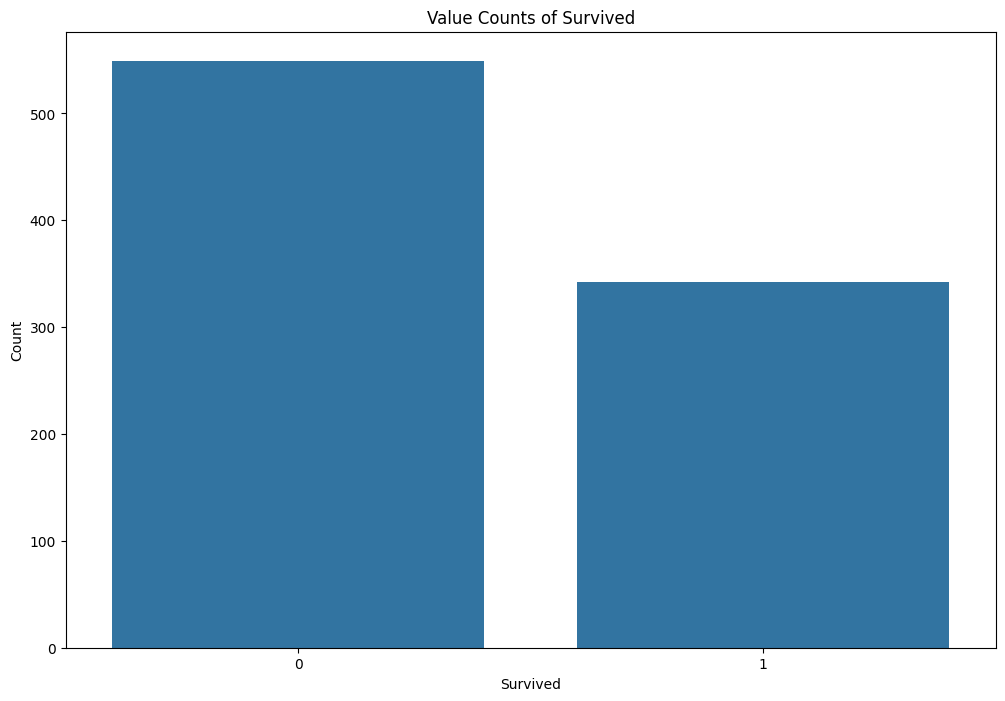

In [4]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

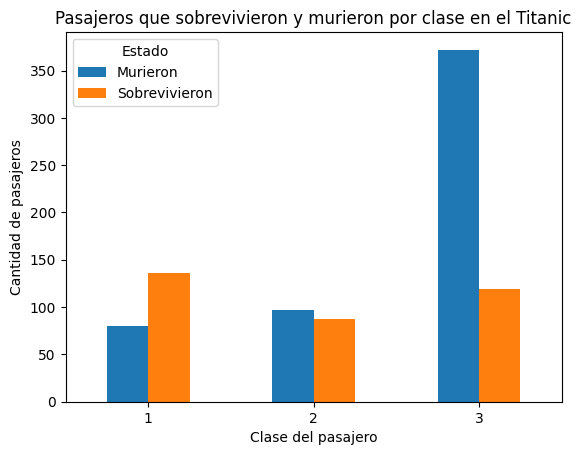

In [ ]:
# Contar sobrevivientes y fallecidos por clase

# Survived: 0 = Murió, 1 = Sobrevivió
survival_counts = df.groupby(['Pclass', 'Survived']).size().unstack()

# Renombrar columnas para mayor claridad
survival_counts.columns = ['Murieron', 'Sobrevivieron']

# Crear gráfica de barras
survival_counts.plot(kind='bar')

# Personalización de la gráfica
plt.title('Pasajeros que sobrevivieron y murieron por clase en el Titanic')
plt.xlabel('Clase del pasajero')
plt.ylabel('Cantidad de pasajeros')
plt.xticks(rotation=0)
plt.legend(title='Estado')

# Mostrar gráfica
plt.show()

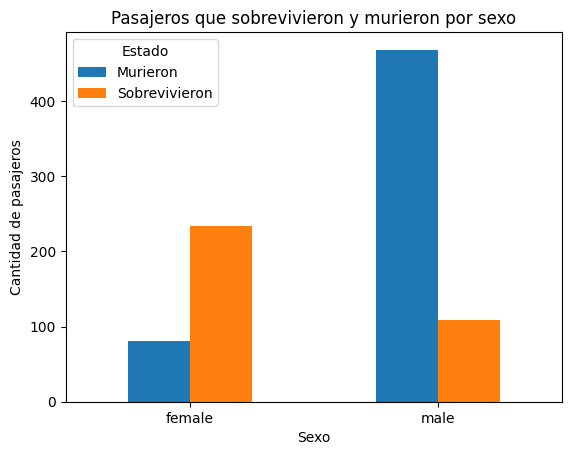

In [7]:
# Contar sobrevivientes y fallecidos por sexo
survival_by_sex = df.groupby(['Sex', 'Survived']).size().unstack()

# Renombrar columnas
survival_by_sex.columns = ['Murieron', 'Sobrevivieron']

# Crear gráfica
survival_by_sex.plot(kind='bar')

# Personalización
plt.title('Pasajeros que sobrevivieron y murieron por sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de pasajeros')
plt.xticks(rotation=0)
plt.legend(title='Estado')

# Mostrar gráfica
plt.show()

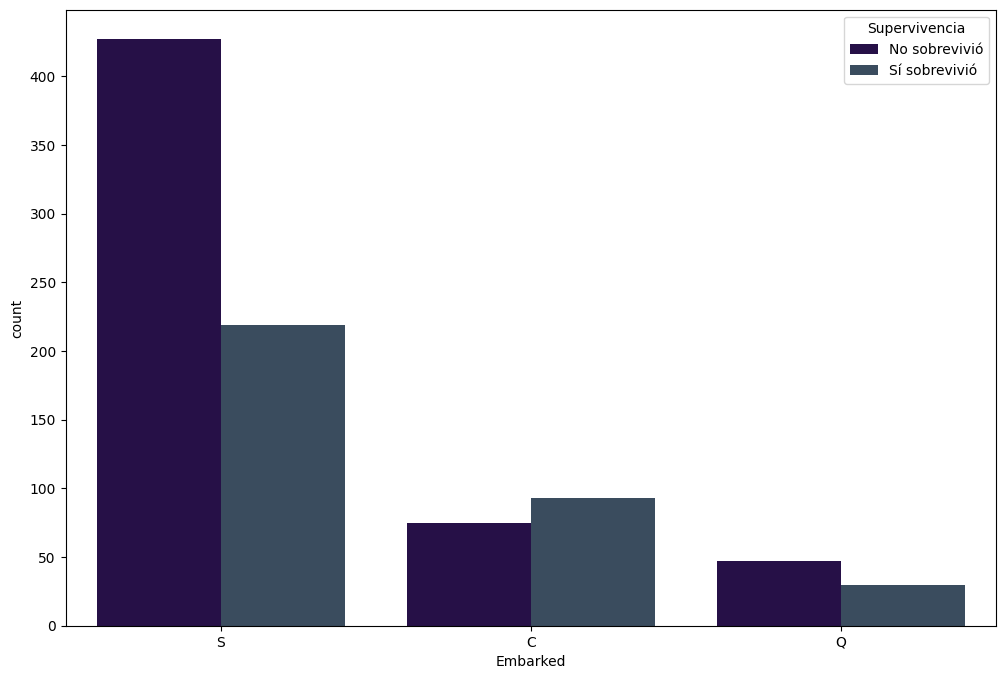

In [8]:
# Contar sobrevivientes y fallecidos por puerto de embarque
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

# Distribución de Edades

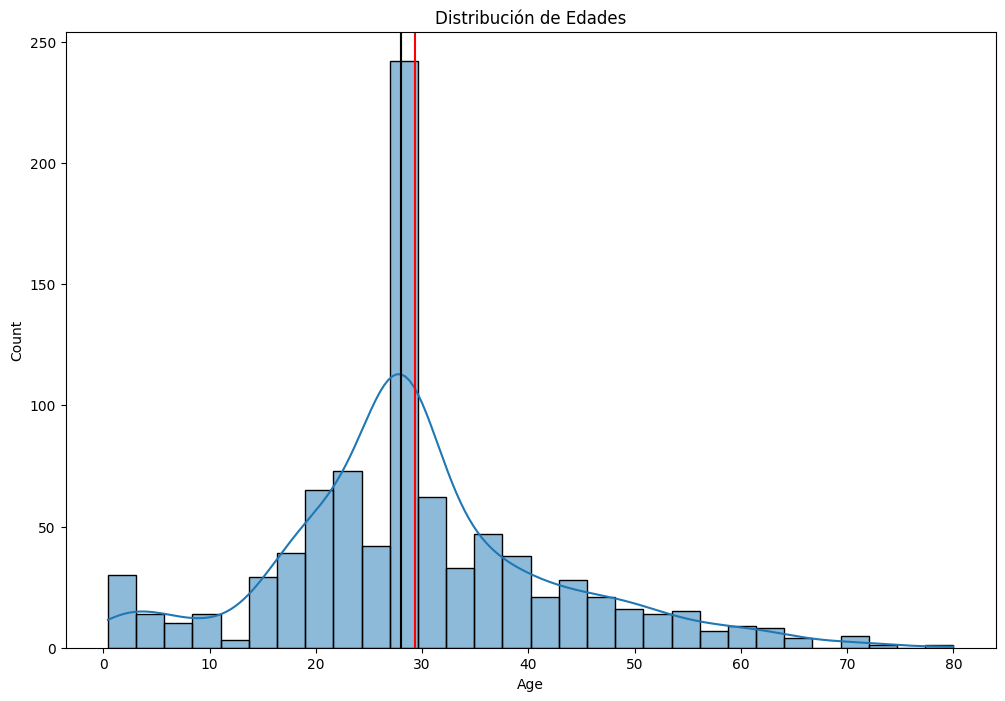

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


In [11]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

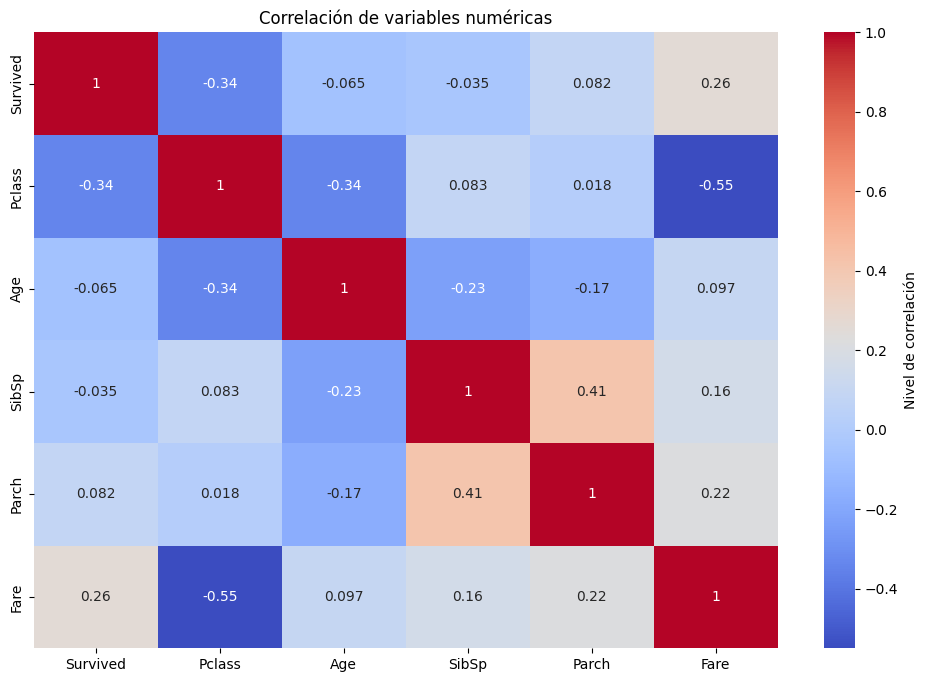

In [12]:
# Correlación entre variables numéricas
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

# Ejercicios 

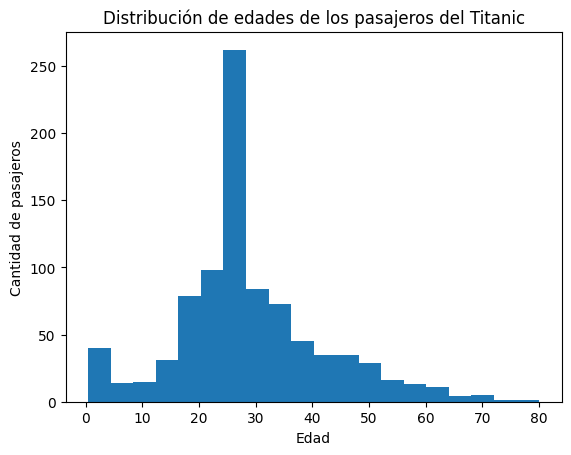

In [14]:
# Crear histograma de edades
plt.hist(df['Age'].dropna(), bins=20)

# Personalización
plt.title('Distribución de edades de los pasajeros del Titanic')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')

# Mostrar gráfica
plt.show()

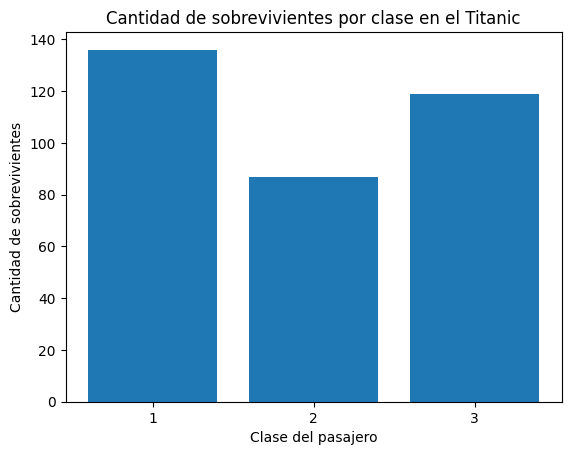

In [16]:
# Crear gráfica de barras para sobrevivientes por clase
# Filtrar solo los sobrevivientes
survivors = df[df['Survived'] == 1]

# Contar sobrevivientes por clase
survivors_by_class = survivors['Pclass'].value_counts().sort_index()

# Crear gráfica
plt.bar(survivors_by_class.index, survivors_by_class.values)

# Personalización
plt.title('Cantidad de sobrevivientes por clase en el Titanic')
plt.xlabel('Clase del pasajero')
plt.ylabel('Cantidad de sobrevivientes')
plt.xticks([1, 2, 3])

# Mostrar gráfica
plt.show()

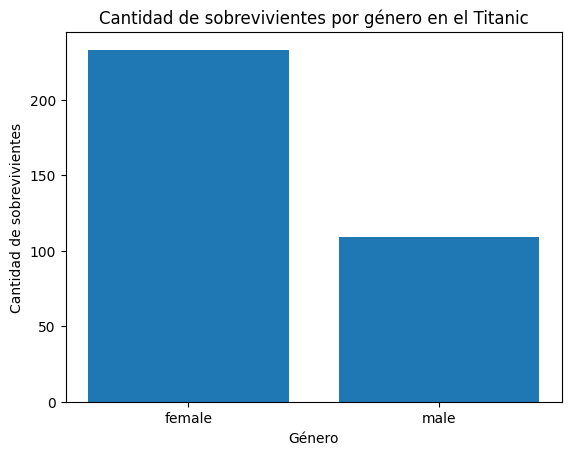

In [17]:
# Crear gráfica de barras para sobrevivientes por género
# Filtrar solo los sobrevivientes
survivors = df[df['Survived'] == 1]

# Contar sobrevivientes por género
survivors_by_gender = survivors['Sex'].value_counts()

# Crear gráfica
plt.bar(survivors_by_gender.index, survivors_by_gender.values)

# Personalización
plt.title('Cantidad de sobrevivientes por género en el Titanic')
plt.xlabel('Género')
plt.ylabel('Cantidad de sobrevivientes')

# Mostrar gráfica
plt.show()

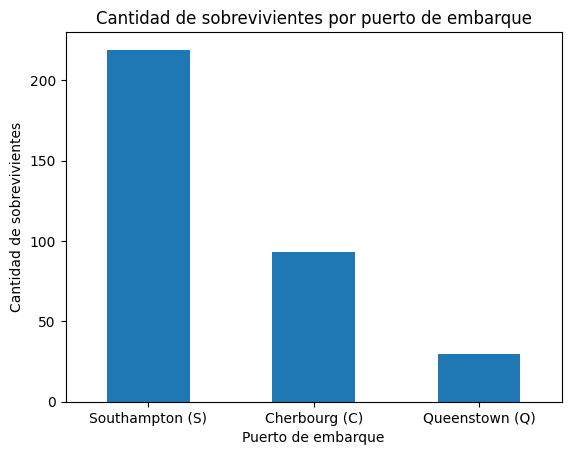

In [18]:
# Crear gráfica de barras para sobrevivientes por puerto de embarque
# Filtrar solo sobrevivientes
survivors = df[df['Survived'] == 1]

# Contar sobrevivientes por puerto de embarque
survivors_by_port = survivors['Embarked'].value_counts()

# Renombrar puertos para mayor claridad
survivors_by_port.index = [
    'Southampton (S)' if x == 'S' else
    'Cherbourg (C)' if x == 'C' else
    'Queenstown (Q)'
    for x in survivors_by_port.index
]

# Crear gráfica
survivors_by_port.plot(kind='bar')

# Personalización
plt.title('Cantidad de sobrevivientes por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad de sobrevivientes')
plt.xticks(rotation=0)

# Mostrar gráfica
plt.show()

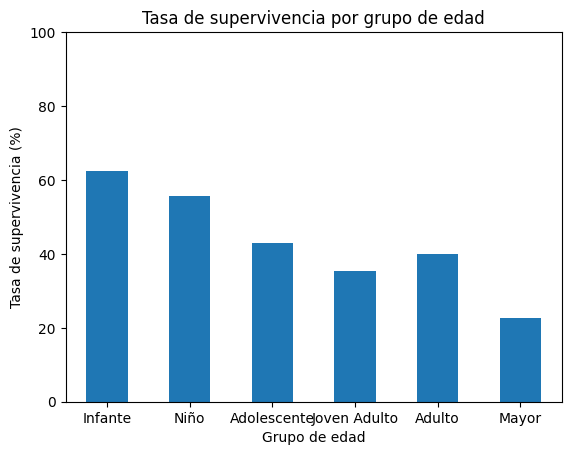

In [19]:
# Crear gráfica de barras para tasa de supervivencia por grupo de edad
# Definir rangos de edad
bins = [0, 2, 12, 18, 35, 60, 100]
labels = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']

# Crear nueva columna con categorías de edad
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Calcular tasa de supervivencia por grupo de edad
# Mean funciona porque Survived es 0 o 1
survival_rate = df.groupby('AgeGroup')['Survived'].mean() * 100

# Crear gráfica
survival_rate.plot(kind='bar')

# Personalización
plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de supervivencia (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)

# Mostrar gráfica
plt.show()

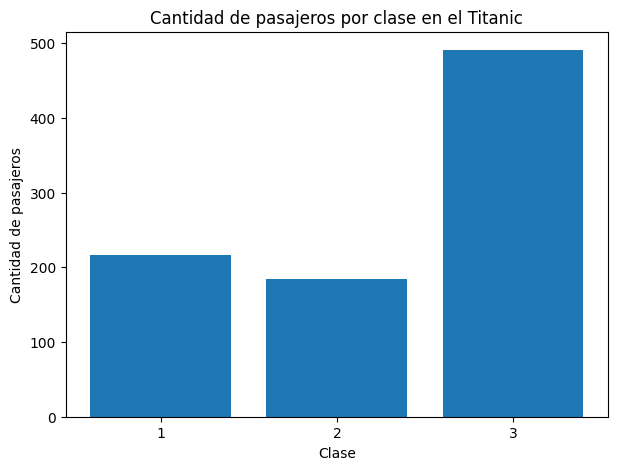

In [20]:
# Crear gráfica de barras para cantidad de pasajeros por clase
# Contar cantidad de pasajeros por clase
class_counts = df['Pclass'].value_counts().sort_index()

# Crear gráfica de barras
plt.figure(figsize=(7,5))
plt.bar(class_counts.index.astype(str), class_counts.values)

# Personalización
plt.title('Cantidad de pasajeros por clase en el Titanic')
plt.xlabel('Clase')
plt.ylabel('Cantidad de pasajeros')

# Mostrar gráfica
plt.show()

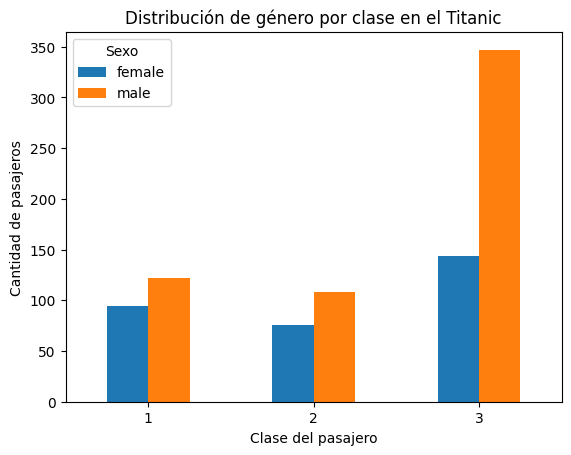

In [21]:
# Crear gráfica de barras para cantidad de pasajeros por sexo
# Contar cantidad de personas por clase y sexo
gender_distribution = df.groupby(['Pclass', 'Sex']).size().unstack()

# Crear gráfica de barras
gender_distribution.plot(kind='bar')

# Personalización
plt.title('Distribución de género por clase en el Titanic')
plt.xlabel('Clase del pasajero')
plt.ylabel('Cantidad de pasajeros')
plt.xticks(rotation=0)
plt.legend(title='Sexo')

# Mostrar gráfica
plt.show()

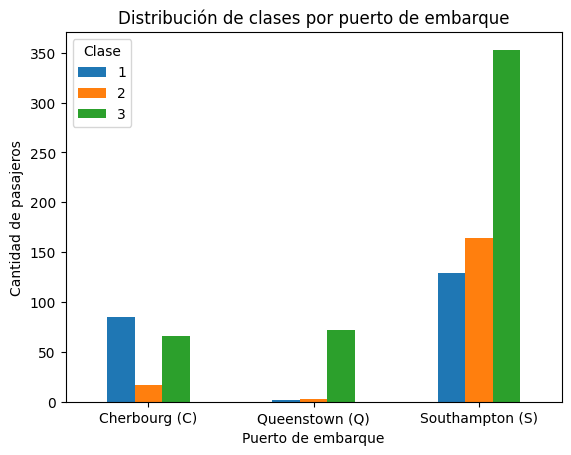

In [22]:
# Crear gráfica de barras para cantidad de pasajeros por puerto de embarque
# Contar pasajeros por puerto de embarque y clase
embarked_distribution = df.groupby(['Embarked', 'Pclass']).size().unstack()

# Crear gráfica de barras
embarked_distribution.plot(kind='bar')

# Personalización
plt.title('Distribución de clases por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad de pasajeros')
plt.xticks(rotation=0)

# Cambiar etiquetas de puertos si deseas
plt.xticks(
    ticks=range(len(embarked_distribution.index)),
    labels=['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)']
)

plt.legend(title='Clase')

# Mostrar gráfica
plt.show()

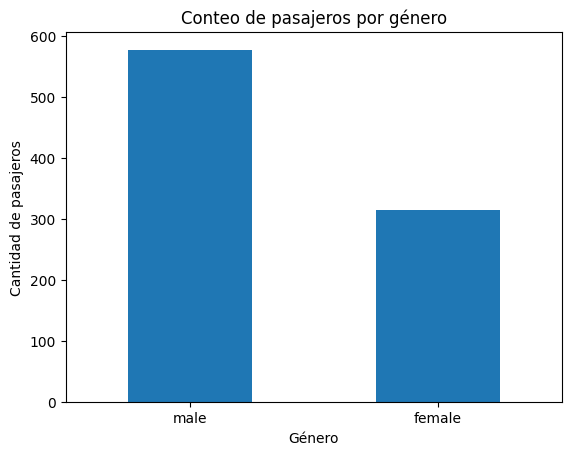

In [23]:
# Crear gráfica de barras para cantidad de pasajeros por género
# Contar pasajeros por género
gender_counts = df['Sex'].value_counts()

# Crear gráfica de barras
gender_counts.plot(kind='bar')

# Personalización
plt.title('Conteo de pasajeros por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de pasajeros')
plt.xticks(rotation=0)

# Mostrar gráfica
plt.show()

In [24]:
# Obtener edad máxima y mínima
edad_maxima = df['Age'].max()
edad_minima = df['Age'].min()

# Mostrar resultados
print("Edad máxima:", edad_maxima)
print("Edad mínima:", edad_minima)

Edad máxima: 80.0
Edad mínima: 0.42


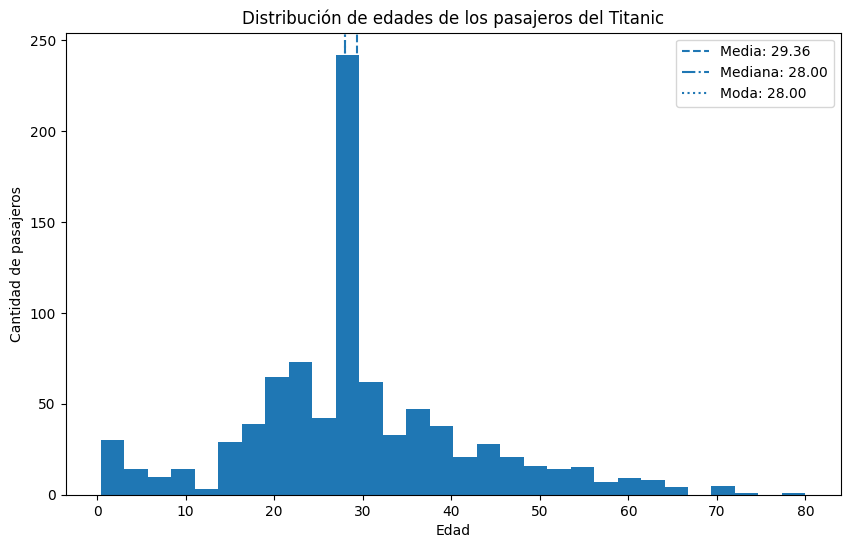

In [25]:
# Crear gráfica de barras para edad máxima y mínima
# Eliminar valores nulos de edad
ages = df['Age'].dropna()

# Calcular estadísticas
mean_age = ages.mean()
median_age = ages.median()
mode_age = ages.mode()[0]

# Crear histograma
plt.figure(figsize=(10, 6))
plt.hist(ages, bins=30)

# Líneas verticales
plt.axvline(mean_age, linestyle='--', label=f'Media: {mean_age:.2f}')
plt.axvline(median_age, linestyle='-.', label=f'Mediana: {median_age:.2f}')
plt.axvline(mode_age, linestyle=':', label=f'Moda: {mode_age:.2f}')

# Personalización
plt.title('Distribución de edades de los pasajeros del Titanic')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.legend()

# Mostrar gráfica
plt.show()

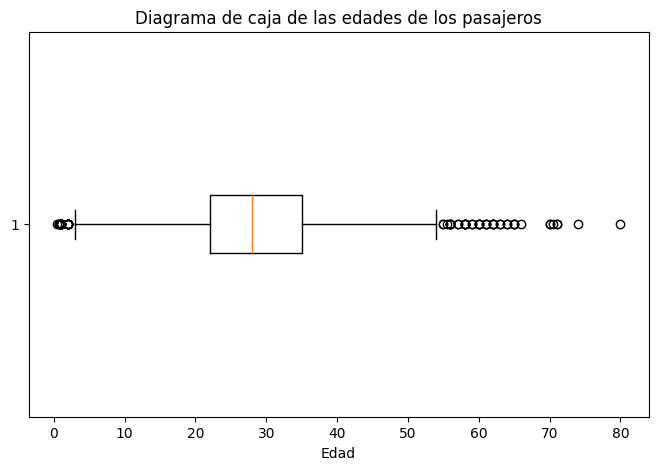

In [26]:
# Crear boxplot para edades de los pasajeros
# Eliminar valores nulos de edad
ages = df['Age'].dropna()

# Crear boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(ages, vert=False)

# Personalización
plt.title('Diagrama de caja de las edades de los pasajeros')
plt.xlabel('Edad')

# Mostrar gráfica
plt.show()

In [27]:
# Obtener tarifa máxima y mínima
tarifa_maxima = df['Fare'].max()
tarifa_minima = df['Fare'].min()

# Mostrar resultados
print("Tarifa máxima:", tarifa_maxima)
print("Tarifa mínima:", tarifa_minima)

Tarifa máxima: 512.3292
Tarifa mínima: 0.0


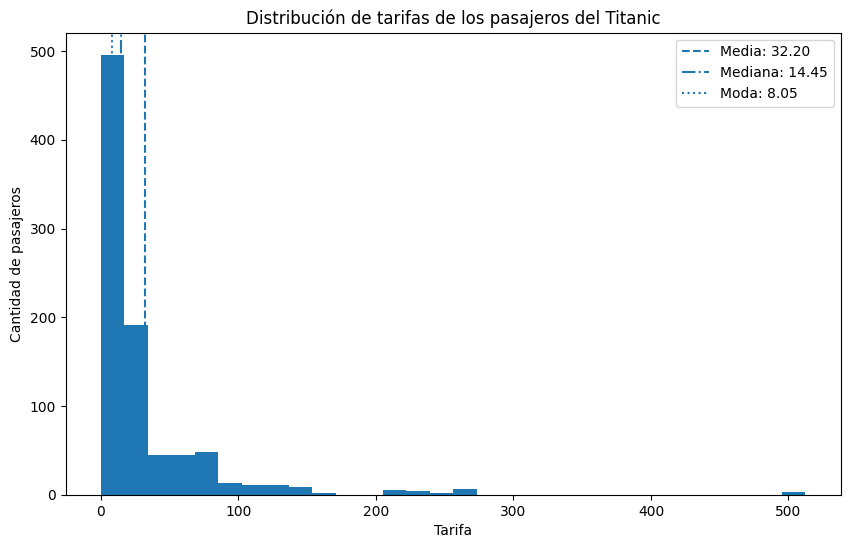

In [28]:
# Crear gráfica de barras para Fare máxima y mínima
# Eliminar valores nulos de Fare
Fare = df['Fare'].dropna()

# Calcular estadísticas
mean_fare = Fare.mean()
median_fare = Fare.median()
mode_fare = Fare.mode()[0]

# Crear histograma
plt.figure(figsize=(10, 6))
plt.hist(Fare, bins=30)

# Líneas verticales
plt.axvline(mean_fare, linestyle='--', label=f'Media: {mean_fare:.2f}')
plt.axvline(median_fare, linestyle='-.', label=f'Mediana: {median_fare:.2f}')
plt.axvline(mode_fare, linestyle=':', label=f'Moda: {mode_fare:.2f}')

# Personalización
plt.title('Distribución de tarifas de los pasajeros del Titanic')
plt.xlabel('Tarifa')
plt.ylabel('Cantidad de pasajeros')
plt.legend()

# Mostrar gráfica
plt.show()

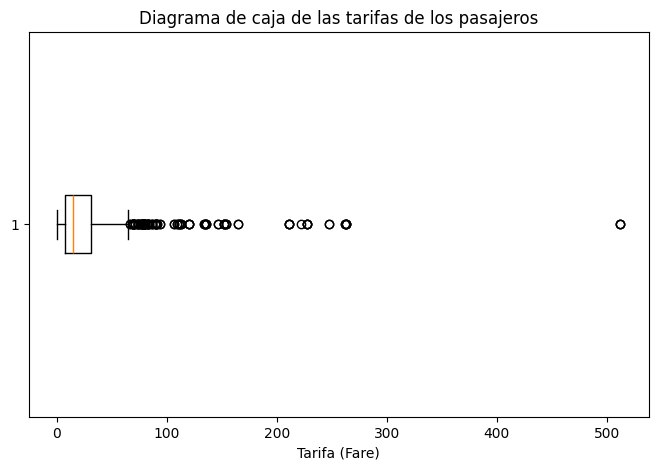

In [29]:
# Crear boxplot para tarifas de los pasajeros
# Eliminar valores nulos de la tarifa
fares = df['Fare'].dropna()

# Crear boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(fares, vert=False)

# Personalización
plt.title('Diagrama de caja de las tarifas de los pasajeros')
plt.xlabel('Tarifa (Fare)')

# Mostrar gráfica
plt.show()

In [30]:
# Filtrar pasajeros con tarifa igual a 0
fare_zero = df[df['Fare'] == 0]

# Mostrar resultados
print(fare_zero)

     Survived  Pclass   Sex   Age  SibSp  Parch  Fare Embarked      AgeGroup
179         0       3  male  36.0      0      0   0.0        S        Adulto
263         0       1  male  40.0      0      0   0.0        S        Adulto
271         1       3  male  25.0      0      0   0.0        S  Joven Adulto
277         0       2  male  28.0      0      0   0.0        S  Joven Adulto
302         0       3  male  19.0      0      0   0.0        S  Joven Adulto
413         0       2  male  28.0      0      0   0.0        S  Joven Adulto
466         0       2  male  28.0      0      0   0.0        S  Joven Adulto
481         0       2  male  28.0      0      0   0.0        S  Joven Adulto
597         0       3  male  49.0      0      0   0.0        S        Adulto
633         0       1  male  28.0      0      0   0.0        S  Joven Adulto
674         0       2  male  28.0      0      0   0.0        S  Joven Adulto
732         0       2  male  28.0      0      0   0.0        S  Joven Adulto

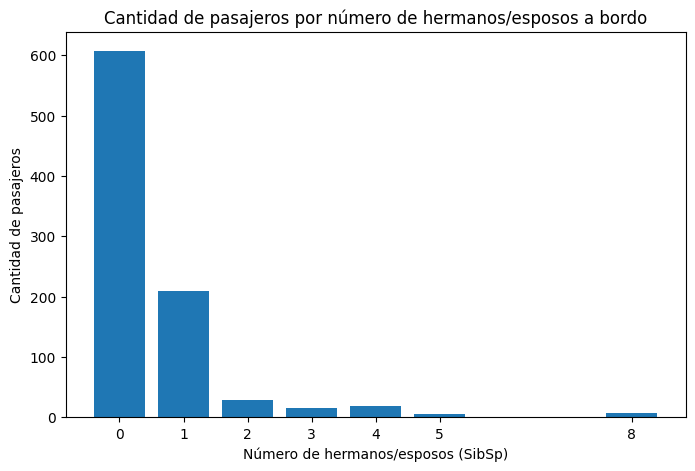

In [31]:
# Crear gráfica de barras para cantidad de pasajeros con tarifa
# Contar pasajeros por número de hermanos/esposos a bordo
sibsp_counts = df['SibSp'].value_counts().sort_index()

# Crear gráfica de barras
plt.figure(figsize=(8, 5))
plt.bar(sibsp_counts.index, sibsp_counts.values)

# Personalización
plt.title('Cantidad de pasajeros por número de hermanos/esposos a bordo')
plt.xlabel('Número de hermanos/esposos (SibSp)')
plt.ylabel('Cantidad de pasajeros')
plt.xticks(sibsp_counts.index)

# Mostrar gráfica
plt.show()

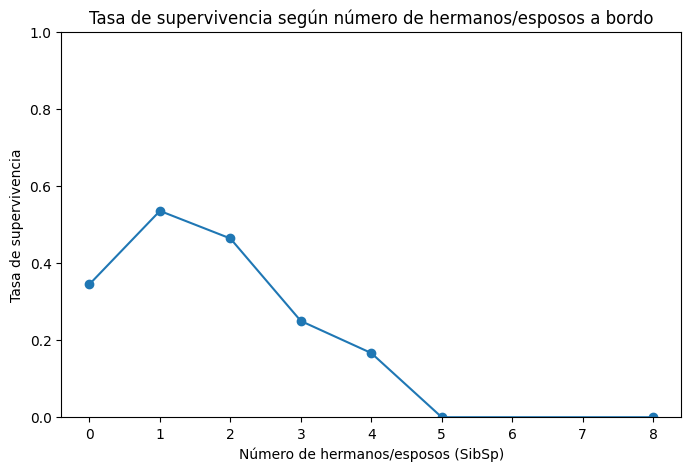

In [32]:
# Crear gráfica de barras para cantidad de pasajeros con tarifa
# Calcular tasa de supervivencia por SibSp
# Survived: 0 = Murió, 1 = Sobrevivió
survival_rate = df.groupby('SibSp')['Survived'].mean()

# Crear gráfica
plt.figure(figsize=(8, 5))
plt.plot(survival_rate.index, survival_rate.values, marker='o')

# Personalización
plt.title('Tasa de supervivencia según número de hermanos/esposos a bordo')
plt.xlabel('Número de hermanos/esposos (SibSp)')
plt.ylabel('Tasa de supervivencia')
plt.ylim(0, 1)

# Mostrar gráfica
plt.show()

In [33]:
# Calcular porcentaje de supervivencia por SibSp
# Multiplicamos por 100 para convertir a porcentaje
survival_percentage = df.groupby('SibSp')['Survived'].mean() * 100

# Mostrar resultados
print(survival_percentage)

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64


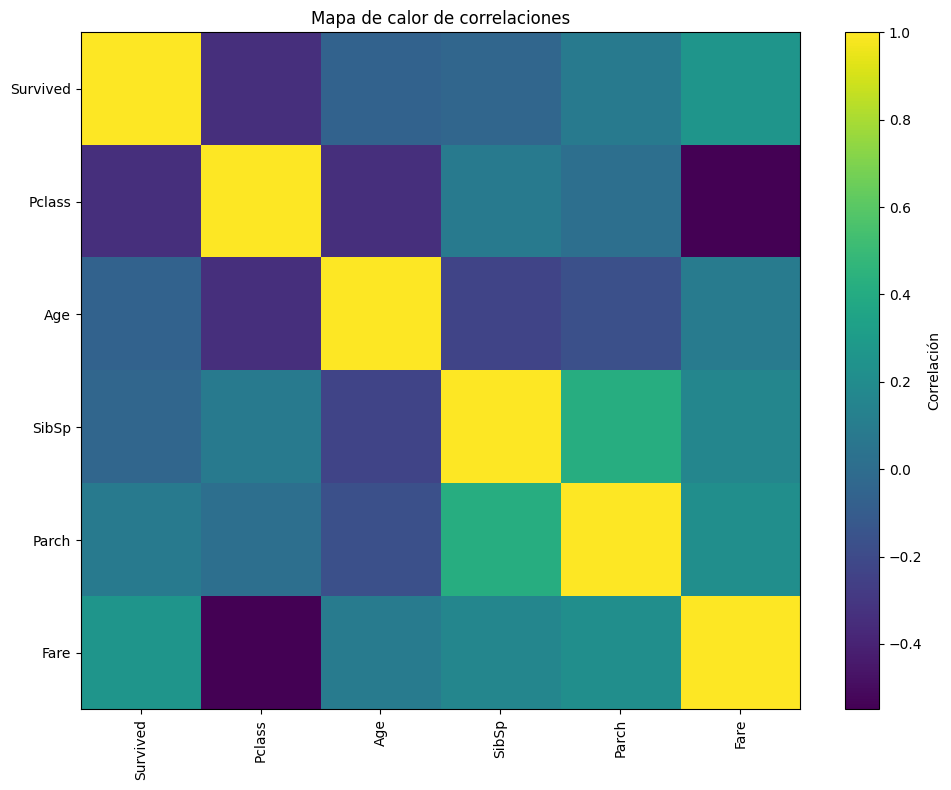

In [34]:
# Crear gráfica de barras para porcentaje de supervivencia por SibSp
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=['number'])

# Calcular matriz de correlación
correlation_matrix = numeric_df.corr()

# Crear figura
plt.figure(figsize=(10, 8))

# Mostrar heatmap
plt.imshow(correlation_matrix, interpolation='nearest', aspect='auto')

# Configurar ejes
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Barra de color
plt.colorbar(label='Correlación')

# Título
plt.title('Mapa de calor de correlaciones')

# Mostrar gráfica
plt.tight_layout()
plt.show()